# SARSA, and how it differs from Q-learning

### One term in the update, and the reason the better policy scores worse

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What on-policy means as one term in one line of code, how to score the policy an agent learned separately from the reward it collected while learning it, why those two numbers disagree on the cliff, what happens to the disagreement as exploration is turned off, and why expected SARSA is usually the one to reach for |
| **You should already know** | [11-04 Q-learning](../04-q-learning/): the temporal-difference update, epsilon-greedy, and the cliff grid |
| **Environment** | The 4 by 12 cliff grid from [11-03](../03-markov-decision-processes/), rebuilt here from its transition model. No `gymnasium`, no RL library |
| **Runtime** | Around two minutes on a laptop CPU |
| **Next** | [11-06 Deep Q-Networks](../06-deep-q-networks/) |

---

## 1. The idea

[11-04](../04-q-learning/) ended on a sentence I want to take apart properly,
because most tellings of this comparison stop one measurement too early.

Q-learning and SARSA differ by one term. Q-learning bootstraps from the best
action available in the next state. SARSA bootstraps from the action it is
actually going to take there, exploration mistakes included. On the cliff grid
that difference produces two different routes, and the usual summary is "SARSA
takes the safe path". True, and not the interesting part.

The interesting part is that the two agents are being scored on two different
things and almost nobody separates them.

**What the agent learned.** Freeze the table, switch exploration off, run the
greedy policy once, and add up the reward. This is what you deploy.

**What the agent collected on the way.** Add up the reward of every episode it
played while learning, exploration and all. This is what the world actually paid
out during training.

Those are different questions and they have different answers here. My claim,
and the thing this notebook exists to measure, is that Q-learning wins the first
and loses the second, at the same time, on the same run. If you only ever plot
the learning curve you see one half of that and conclude SARSA is better. If you
only ever evaluate the final policy you see the other half and conclude
Q-learning is better. Both conclusions are half right.

Then a third method, expected SARSA, which is one line different again and
usually beats both.

### The grid

The same 4 by 12 board as [11-03](../03-markov-decision-processes/) and
[11-04](../04-q-learning/), so all three chapters describe the same world. Start
at the bottom left, goal at the bottom right, cliff in between.

I build it here the way 11-03 does, as an explicit transition array `P` and
reward array `R`, and then sample transitions out of those arrays. That keeps the
world the learner walks in and the world I score policies against provably the
same object, which matters in a notebook whose whole point is comparing two
scores.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
SEEDS = (0, 1, 2)

ROWS, COLS = 4, 12
N_STATES, N_ACTIONS = ROWS * COLS, 4
UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
MOVES = {UP: (-1, 0), RIGHT: (0, 1), DOWN: (1, 0), LEFT: (0, -1)}
ARROWS = {UP: "↑", RIGHT: "→", DOWN: "↓", LEFT: "←"}

START = (ROWS - 1, 0)
GOAL = (ROWS - 1, COLS - 1)

STEP_COST = -1.0
CLIFF_COST = -100.0
GAMMA = 1.0          # the task ends, so nothing has to be discounted to stay finite

In [2]:
def index(cell):
    return cell[0] * COLS + cell[1]


def is_cliff(cell):
    row, col = cell
    return row == ROWS - 1 and 0 < col < COLS - 1


def move(cell, action):
    """Where the agent lands. Walls are sticky: bumping the edge leaves you put."""
    d_row, d_col = MOVES[action]
    row = min(max(cell[0] + d_row, 0), ROWS - 1)
    col = min(max(cell[1] + d_col, 0), COLS - 1)
    return row, col


def build_model():
    """11-03's model builder, with the switches this chapter does not need removed."""
    P = np.zeros((N_STATES, N_ACTIONS, N_STATES))
    R = np.zeros((N_STATES, N_ACTIONS))

    for s in range(N_STATES):
        cell = divmod(s, COLS)
        # The goal and the cliff squares are absorbing rows with no reward. They
        # keep P square without ever contributing to a sum.
        if cell == GOAL or is_cliff(cell):
            P[s, :, s] = 1.0
            continue
        for a in range(N_ACTIONS):
            landed = move(cell, a)
            if is_cliff(landed):
                s_next, reward = index(START), CLIFF_COST
            else:
                s_next, reward = index(landed), STEP_COST
            P[s, a, s_next] = 1.0
            R[s, a] = reward

    return P, R


P, R = build_model()
TERMINAL = index(GOAL)

# Nothing in this world is random, so every P[s, a] is a single 1.0 and the whole
# transition array collapses to one landing square per state-action pair. Keeping
# both means the learner below can walk the world at array-lookup speed while the
# model it was derived from is still on hand to be printed.
NEXT = P.argmax(axis=2)
ROW_IX, COL_IX = np.arange(N_STATES)[:, None], np.arange(N_ACTIONS)[None, :]


def sample_step(s, a):
    """One transition, read off the model. Nothing here is random, so no rng."""
    s_next = int(NEXT[s, a])
    return s_next, float(R[s, a]), s_next == TERMINAL


for row in range(ROWS):
    print("".join(" S" if (row, col) == START else
                  " G" if (row, col) == GOAL else
                  " #" if is_cliff((row, col)) else " ."
                  for col in range(COLS)))
print(f"\nS start, G goal, # cliff. A {ROWS} by {COLS} grid, so {N_STATES} states "
      f"numbered row-major from 0, and {N_ACTIONS} actions.")
print(f"P shape {P.shape}, R shape {R.shape}, every row of P sums to 1: "
      f"{np.allclose(P.sum(axis=2), 1.0)}")
print(f"NEXT carries all the probability in P: "
      f"{P[ROW_IX, COL_IX, NEXT].min() == 1.0}")
print(f"step {STEP_COST:.0f}, cliff {CLIFF_COST:.0f} and back to the start, "
      f"goal ends the episode")

 . . . . . . . . . . . .
 . . . . . . . . . . . .
 . . . . . . . . . . . .
 S # # # # # # # # # # G

S start, G goal, # cliff. A 4 by 12 grid, so 48 states numbered row-major from 0, and 4 actions.
P shape (48, 4, 48), R shape (48, 4), every row of P sums to 1: True
NEXT carries all the probability in P: True
step -1, cliff -100 and back to the start, goal ends the episode


### Two reference routes, priced before anything learns

Two routes matter for the rest of the notebook, and I want their scores printed
now so that every later number has something to be compared against. Both climb
out of the start square, walk right, and drop into the goal. They differ only in
which row they walk along.

In [3]:
def route_policy(travel_row):
    """Climb to `travel_row`, walk right along it, then drop into the goal."""
    pi = np.full(N_STATES, RIGHT, dtype=int)
    for s in range(N_STATES):
        row, col = divmod(s, COLS)
        if col == COLS - 1:
            pi[s] = DOWN
        elif row > travel_row:
            pi[s] = UP
    return pi


def rollout(pi, cap=400):
    """Run a deterministic policy from the start and score it. No exploration."""
    s = index(START)
    total, falls, path, reached = 0.0, 0, [START], False
    for _ in range(cap):
        s_next, reward, done = sample_step(s, int(pi[s]))
        total += reward
        if reward == CLIFF_COST:
            falls += 1
        s = s_next
        path.append(divmod(s, COLS))
        if done:
            reached = True
            break
    return {"return": total, "steps": len(path) - 1, "falls": falls,
            "reached": reached, "path": path}


EDGE = rollout(route_policy(ROWS - 2))     # one row above the cliff
OVER = rollout(route_policy(ROWS - 3))     # two rows above the cliff

print(f"cliff-edge route : {EDGE['steps']:2d} steps, return {EDGE['return']:6.0f}")
print(f"one row higher   : {OVER['steps']:2d} steps, return {OVER['return']:6.0f}")
print(f"\nthe edge route is worth {EDGE['return'] - OVER['return']:+.0f} to an agent "
      f"that never makes a random move")

cliff-edge route : 13 steps, return    -13
one row higher   : 15 steps, return    -15

the edge route is worth +2 to an agent that never makes a random move


## 2. The maths

All three methods run the same skeleton. Watch a transition
$(s, a, r, s')$, form a **target** for $Q(s,a)$, and step toward it:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\big[\text{target} - Q(s,a)\big]$$

Everything that separates them is inside that word.

| | target | what it assumes happens next |
|---|---|---|
| Q-learning | $r + \gamma \max_{a'} Q(s', a')$ | the best action available |
| SARSA | $r + \gamma\, Q(s', a')$ | the action actually drawn, $a' \sim \pi$ |
| expected SARSA | $r + \gamma \sum_{a'} \pi(a' \mid s')\, Q(s', a')$ | every action, weighted by how likely it is |

SARSA is named after the five things its update touches, $s, a, r, s', a'$, and
the fifth one is the whole story.

### What each one converges to

Q-learning's target does not mention $\pi$ anywhere, so its fixed point is
$Q^*$: the value of behaving optimally, whatever the agent is actually doing
while it learns. That is what **off-policy** means. The behaviour is a way of
generating data, and the thing being estimated is somebody else's policy.

SARSA's target contains an action drawn from the policy the agent is running, so
its fixed point is $Q^\pi$ for that policy, epsilon-greedy exploration included.
That is **on-policy**. If the policy keeps making random moves, SARSA's estimates
say what those random moves are worth, and a square beside a cliff is worth less
to an agent that sometimes steps sideways by accident.

So the difference is not really about caution. SARSA is not being timid, it is
answering a different question, and on this grid the honest answer to its
question is a route with clearance.

### Expected SARSA

Expected SARSA asks SARSA's question and answers it without the dice. Instead of
bootstrapping from one sampled $a'$, it averages over every action the policy
might take, weighted by its probability. Same expectation, none of the sampling
noise from $a'$.

$$\sum_{a'} \pi(a' \mid s')\, Q(s', a')
= (1 - \varepsilon)\max_{a'} Q(s', a') + \frac{\varepsilon}{|\mathcal{A}|}\sum_{a'} Q(s', a')$$

Two things fall out of that line and both get measured in section 5.

The first is the cost. Every action outside the argmax carries the same
probability, so the sum is a max and a mean over four numbers and nothing more.
In exchange, one of the two sources of noise in the update disappears. The
environment here is deterministic, so it was the *only* source of noise, which
means expected SARSA should tolerate a step size that makes SARSA thrash.

The second is what happens as $\varepsilon \to 0$. The right-hand side collapses
to $\max_{a'} Q(s', a')$, which is Q-learning's target exactly. The three methods
are not three philosophies. They are one family with $\varepsilon$ as the dial,
and at one end of the dial they are the same algorithm.

## 3. From scratch

One function, one `if`. Everything else is shared, on purpose, so that any
difference in the results has exactly one place it could have come from.

In [4]:
METHODS = ("q-learning", "sarsa", "expected sarsa")


def policy_probs(q_row, epsilon):
    """The epsilon-greedy distribution over actions in one state."""
    probs = np.full(N_ACTIONS, epsilon / N_ACTIONS)
    probs[int(q_row.argmax())] += 1.0 - epsilon
    return probs


def expected_q(q_row, epsilon):
    """Sum over actions of pi(a|s) Q(s,a), written out rather than built as a vector.

    The epsilon/|A| term applied to every action is epsilon times the mean, so the
    whole expectation is two reductions over four numbers.
    """
    return (1.0 - epsilon) * q_row.max() + epsilon * q_row.mean()


def choose(Q, s, epsilon, rng):
    """Explore with probability epsilon, otherwise take the best known action.

    The rng.random() draw happens whatever epsilon is, so two methods run with the
    same seed and the same epsilon consume the random stream identically.
    """
    if rng.random() < epsilon:
        return int(rng.integers(N_ACTIONS))
    return int(Q[s].argmax())


def train(method, episodes=500, alpha=0.5, gamma=GAMMA, epsilon=0.1, seed=SEED, cap=400):
    """Tabular TD control. The three methods differ only in `target`."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    totals = np.zeros(episodes)

    for ep in range(episodes):
        s = index(START)
        a = choose(Q, s, epsilon, rng)
        total = 0.0

        for _ in range(cap):                  # cap so a bad policy cannot hang
            s_next, reward, done = sample_step(s, a)
            total += reward
            a_next = choose(Q, s_next, epsilon, rng)

            if done:
                target = reward               # nothing follows a terminal state
            elif method == "q-learning":
                target = reward + gamma * Q[s_next].max()
            elif method == "sarsa":
                target = reward + gamma * Q[s_next, a_next]
            else:
                target = reward + gamma * expected_q(Q[s_next], epsilon)

            Q[s, a] += alpha * (target - Q[s, a])
            s, a = s_next, a_next
            if done:
                break

        totals[ep] = total

    return Q, totals


started = time.perf_counter()
tables, curves = {}, {}
for method in METHODS:
    for seed in SEEDS:
        tables[method, seed], curves[method, seed] = train(method, seed=seed)
EPISODES = len(curves[METHODS[0], SEEDS[0]])
print(f"{len(METHODS)} methods x {len(SEEDS)} seeds x {EPISODES} episodes "
      f"[{time.perf_counter() - started:.1f}s]")

3 methods x 3 seeds x 500 episodes [0.9s]


### The three targets, on one state

Before any comparison of routes, here are the three numbers side by side. I take
a trained table, pick the square directly above the middle of the cliff, and read
off what each method would use as the bootstrap term if the agent landed there.

One of the four actions in that square steps off the cliff. That is what makes it
a good place to look: the four action values are far apart, so the choice of how
to summarise them shows up as a large number rather than a rounding difference.

In [5]:
PROBE = index((ROWS - 2, COLS // 2))
EPSILON = 0.1
Q_probe = tables["q-learning", SEED]

max_target = float(Q_probe[PROBE].max())
probs = policy_probs(Q_probe[PROBE], EPSILON)
expected_target = float(probs @ Q_probe[PROBE])

print(f"state {PROBE} = row {PROBE // COLS}, column {PROBE % COLS}, "
      f"directly above the cliff\n")
print(pd.DataFrame({"action": [ARROWS[a] for a in range(N_ACTIONS)],
                    "lands on the cliff": [is_cliff(move(divmod(PROBE, COLS), a))
                                           for a in range(N_ACTIONS)],
                    "Q(s', a)": Q_probe[PROBE],
                    f"probability at ε={EPSILON}": probs}
                   ).to_string(index=False, float_format="{:.3f}".format))
print(f"\nQ-learning bootstraps from   max Q(s', a')          = {max_target:8.3f}")
print(f"expected SARSA bootstraps from  E_pi[Q(s', a')]      = {expected_target:8.3f}")
print(f"SARSA bootstraps from one draw, so it gets {max_target:.3f} with probability "
      f"{probs.max():.3f}")
print(f"and one of the other three values otherwise, the worst of them being "
      f"{Q_probe[PROBE].min():.3f}")
print(f"\ngap between the optimistic target and the on-policy one: "
      f"{max_target - expected_target:.3f}")
print(f"the training loop's shortcut agrees with the explicit sum: "
      f"{np.isclose(expected_q(Q_probe[PROBE], EPSILON), expected_target)}")

state 30 = row 2, column 6, directly above the cliff

action  lands on the cliff  Q(s', a)  probability at ε=0.1
     ↑               False    -7.979                 0.025
     →               False    -6.000                 0.925
     ↓                True  -112.999                 0.025
     ←               False    -7.999                 0.025

Q-learning bootstraps from   max Q(s', a')          =   -6.000
expected SARSA bootstraps from  E_pi[Q(s', a')]      =   -8.774
SARSA bootstraps from one draw, so it gets -6.000 with probability 0.925
and one of the other three values otherwise, the worst of them being -112.999

gap between the optimistic target and the on-policy one: 2.774
the training loop's shortcut agrees with the explicit sum: True


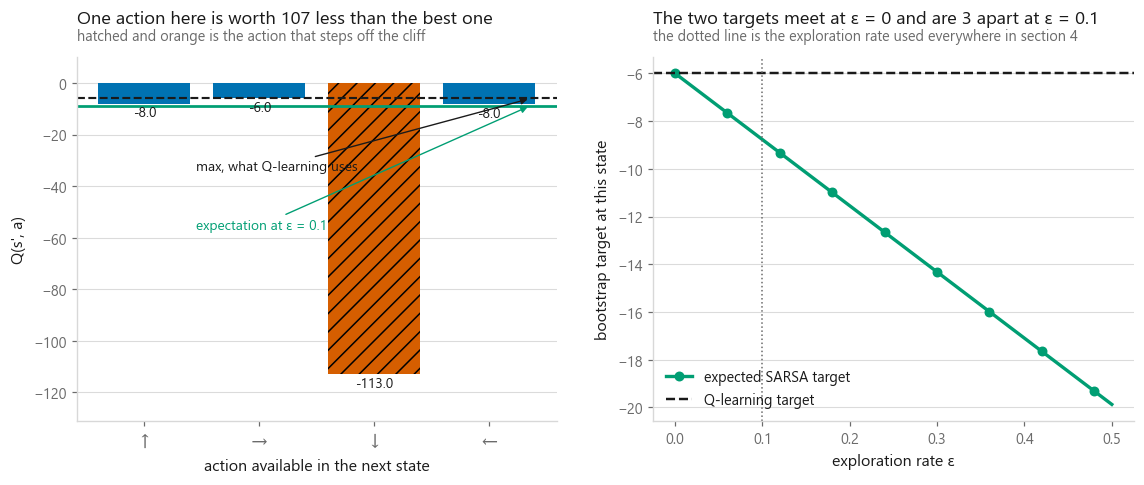

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

ax = axes[0]
worst = float(Q_probe[PROBE].min())
bars = ax.bar(range(N_ACTIONS), Q_probe[PROBE],
              color=[style.HIGHLIGHT if is_cliff(move(divmod(PROBE, COLS), a))
                     else style.PALETTE[0] for a in range(N_ACTIONS)],
              hatch=["//" if is_cliff(move(divmod(PROBE, COLS), a)) else ""
                     for a in range(N_ACTIONS)])
ax.bar_label(bars, fmt="%.1f", fontsize=9, color=style.INK, padding=2)
ax.set_ylim(worst * 1.16, abs(worst) * 0.09)
ax.axhline(max_target, color=style.INK, lw=1.4, ls="--")
ax.axhline(expected_target, color=style.PALETTE[2], lw=1.8, ls="-")
ax.annotate("max, what Q-learning uses", xy=(3.36, max_target), xytext=(0.45, worst * 0.30),
            fontsize=9, color=style.INK, ha="left",
            arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=0.9))
ax.annotate(f"expectation at ε = {EPSILON}", xy=(3.36, expected_target),
            xytext=(0.45, worst * 0.50), fontsize=9, color=style.PALETTE[2], ha="left",
            arrowprops=dict(arrowstyle="-|>", color=style.PALETTE[2], lw=0.9))
ax.set_xticks(range(N_ACTIONS), [f"{ARROWS[a]}" for a in range(N_ACTIONS)], fontsize=14)
ax.set_ylabel("Q(s', a)")
ax.set_xlabel("action available in the next state")
style.title(ax, f"One action here is worth {max_target - worst:.0f} less than the best one",
            "hatched and orange is the action that steps off the cliff")

ax = axes[1]
eps_grid = np.linspace(0.0, 0.5, 101)
expected_curve = np.array([policy_probs(Q_probe[PROBE], e) @ Q_probe[PROBE] for e in eps_grid])
ax.plot(eps_grid, expected_curve, color=style.PALETTE[2], lw=2.2,
        marker=style.MARKERS[0], markevery=12, label="expected SARSA target")
ax.axhline(max_target, color=style.INK, lw=1.6, ls="--", label="Q-learning target")
ax.axvline(EPSILON, color=style.MUTED, lw=1.0, ls=":")
ax.set_xlabel("exploration rate ε")
ax.set_ylabel("bootstrap target at this state")
ax.legend(loc="lower left")
style.title(ax, f"The two targets meet at ε = 0 and are {max_target - expected_target:.0f} apart at ε = {EPSILON}",
            "the dotted line is the exploration rate used everywhere in section 4")

style.save(fig, FIG / "fig-01-three-targets.png")

The right panel is the argument of the whole chapter in one line. There is no
philosophical difference between these methods, there is a gap that is a function
of $\varepsilon$, and section 5 walks that gap down to zero.

## 4. What each one learned, and what each one collected

Now the two scores. For each method and each seed I take the final table, read
off its greedy policy, and run that policy once with exploration switched off.
The environment is deterministic, so one run is the exact answer and there is no
sampling error in this column at all.

q-learning      greedy route  13 steps, 0 falls, return     -13, reached the goal: True
sarsa           greedy route  17 steps, 0 falls, return     -17, reached the goal: True
expected sarsa  greedy route  15 steps, 0 falls, return     -15, reached the goal: True

for reference, the cliff-edge route is -13 and the row above it is -15


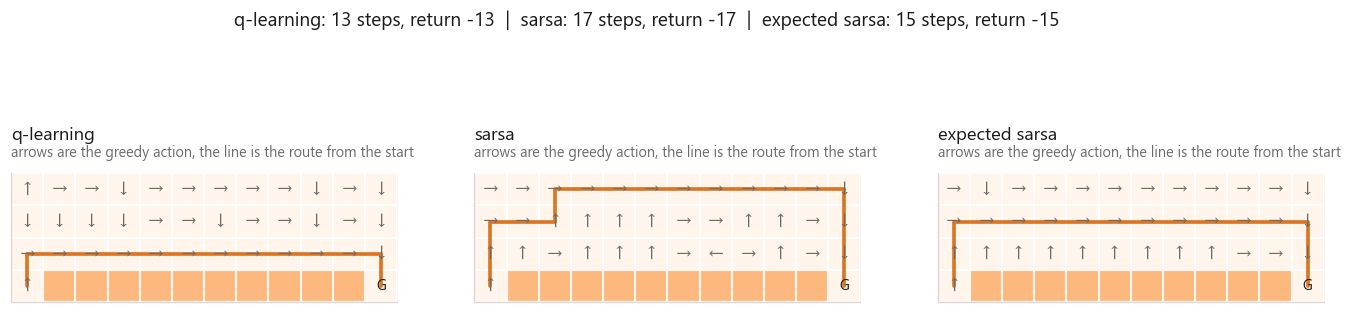

In [7]:
def decorate(ax):
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.4)
    ax.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
    ax.grid(which="major", visible=False)


def draw_policy(ax, Q, headline, sub=None):
    board = np.zeros((ROWS, COLS))
    board[ROWS - 1, 1:COLS - 1] = 1.0
    ax.imshow(board, cmap="Oranges", vmin=0, vmax=3.0)

    for s in range(N_STATES):
        cell = divmod(s, COLS)
        if is_cliff(cell) or cell == GOAL:
            continue
        ax.text(cell[1], cell[0], ARROWS[int(Q[s].argmax())], ha="center", va="center",
                fontsize=13, color=style.MUTED)

    run = rollout(Q.argmax(axis=1))
    ax.plot([c for _, c in run["path"]], [r for r, _ in run["path"]],
            color=style.HIGHLIGHT, lw=2.4, alpha=0.85, solid_capstyle="round")
    ax.text(GOAL[1], GOAL[0], "G", ha="center", va="center", fontsize=9.5, color=style.INK)
    decorate(ax)
    style.title(ax, headline, sub)
    return run


fig, axes = plt.subplots(1, 3, figsize=(15.4, 3.3))
runs = {}
for ax, method in zip(axes, METHODS):
    run = draw_policy(ax, tables[method, SEED], method,
                      "arrows are the greedy action, the line is the route from the start")
    runs[method] = run
fig.suptitle(
    "  |  ".join(f"{m}: {runs[m]['steps']} steps, return {runs[m]['return']:.0f}"
                 for m in METHODS),
    x=0.5, y=1.12, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-routes.png")

for method in METHODS:
    run = runs[method]
    print(f"{method:<15} greedy route {run['steps']:3d} steps, "
          f"{run['falls']} falls, return {run['return']:7.0f}, "
          f"reached the goal: {run['reached']}")
print(f"\nfor reference, the cliff-edge route is {EDGE['return']:.0f} "
      f"and the row above it is {OVER['return']:.0f}")

In [8]:
rows = []
for method in METHODS:
    greedy = [rollout(tables[method, s].argmax(axis=1)) for s in SEEDS]
    rows.append({
        "method": method,
        "online, all episodes": np.mean([curves[method, s].mean() for s in SEEDS]),
        "online, last 100": np.mean([curves[method, s][-100:].mean() for s in SEEDS]),
        "greedy policy at the end": np.mean([g["return"] for g in greedy]),
        "greedy route, steps": np.mean([g["steps"] for g in greedy]),
        "seeds reaching the goal": sum(g["reached"] for g in greedy),
    })
scores = pd.DataFrame(rows)

print(f"mean over {len(SEEDS)} seeds, {EPISODES} episodes each, ε = {EPSILON}, "
      f"α = 0.5, γ = {GAMMA:.0f}")
print(scores.to_string(index=False, float_format="{:.1f}".format))

best_online = scores.loc[scores["online, last 100"].idxmax(), "method"]
best_greedy = scores.loc[scores["greedy policy at the end"].idxmax(), "method"]
print(f"\nbest while learning : {best_online}")
print(f"best policy learned : {best_greedy}")

mean over 3 seeds, 500 episodes each, ε = 0.1, α = 0.5, γ = 1
        method  online, all episodes  online, last 100  greedy policy at the end  greedy route, steps  seeds reaching the goal
    q-learning                 -55.1             -48.0                     -13.0                 13.0                        3
         sarsa                 -34.1             -24.4                     -17.0                 17.0                        3
expected sarsa                 -28.6             -21.2                     -15.0                 15.0                        3

best while learning : expected sarsa
best policy learned : q-learning


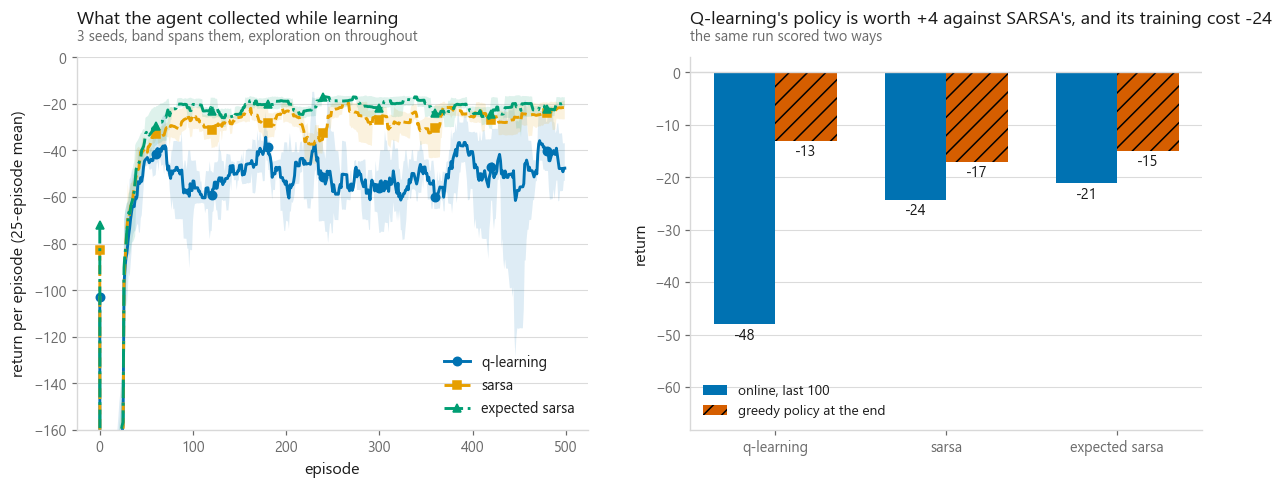

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.4))

ax = axes[0]
for i, method in enumerate(METHODS):
    stacked = np.stack([curves[method, s] for s in SEEDS])
    smooth = pd.DataFrame(stacked.T).rolling(25, min_periods=1).mean().to_numpy()
    ax.fill_between(np.arange(smooth.shape[0]), smooth.min(1), smooth.max(1),
                    color=style.PALETTE[i], alpha=0.13, linewidth=0)
    ax.plot(smooth.mean(1), color=style.PALETTE[i], lw=1.9, ls=style.DASHES[i],
            marker=style.MARKERS[i], markevery=60, label=method)
ax.set_ylim(-160, 0)
ax.set_xlabel("episode")
ax.set_ylabel("return per episode (25-episode mean)")
ax.legend(loc="lower right")
style.title(ax, "What the agent collected while learning",
            f"{len(SEEDS)} seeds, band spans them, exploration on throughout")

ax = axes[1]
x = np.arange(len(METHODS))
width = 0.36
floor = min(scores["online, last 100"].min(), scores["greedy policy at the end"].min())
for i, (column, colour, hatch) in enumerate(
        [("online, last 100", style.PALETTE[0], ""),
         ("greedy policy at the end", style.HIGHLIGHT, "//")]):
    bars = ax.bar(x + (i - 0.5) * width, scores[column].to_numpy(), width,
                  color=colour, hatch=hatch, label=column)
    ax.bar_label(bars, fmt="%.0f", fontsize=9.5, color=style.INK, padding=2)
ax.set_xticks(x, METHODS, fontsize=9.5)
ax.set_ylim(floor * 1.42, abs(floor) * 0.06)
ax.set_ylabel("return")
ax.axhline(0, color=style.RULE, lw=0.9)
ax.legend(loc="lower left", fontsize=9)
q_row = scores.set_index("method").loc["q-learning"]
s_row = scores.set_index("method").loc["sarsa"]
style.title(
    ax,
    f"Q-learning's policy is worth {q_row['greedy policy at the end'] - s_row['greedy policy at the end']:+.0f} "
    f"against SARSA's, and its training cost {q_row['online, last 100'] - s_row['online, last 100']:+.0f}",
    "the same run scored two ways")

style.save(fig, FIG / "fig-03-online-versus-greedy.png")

### Reading the two bars together

The right panel is the measurement this chapter was written for. The two bars
over each method are the same agent, the same seed, the same training run. Only
the question changed.

Q-learning's greedy bar is the tallest of the greedy bars, and it should be
compared against the cliff-edge route priced at the top of the notebook, which is
the best route this grid allows. Its online bar is the shortest of the online
bars. One move in ten is random and its route runs along squares where a single
random step downward costs a hundred and sends it back to the start. It learned
the better policy and paid for it in every episode of training.

The on-policy pair go the other way. That is not caution for its own sake. Their
target contains the action the agent is genuinely about to take, so what they
converge to is the value of an agent that keeps stepping sideways at random. For
that agent the squares beside the cliff really are worth less, and the route with
clearance really is the better one. They are estimating the right quantity for
the behaviour they are running.

Expected SARSA answers SARSA's question with an average instead of a draw, so
there is one less thing wobbling in every update. Whether that shows up as a
better number at this learning rate is the last panel of the notebook.

The practical version of all this is a single question about deployment. Will the
exploration still be switched on when this thing is running for real? In a
simulator you will train and then deploy the argmax, so Q-learning's answer is
the one you want and its training cost is fake, paid in a world that does not
exist. On hardware with noisy actuators, or a live recommender still running an
experiment, the random moves are real and permanent, and SARSA is estimating the
thing you actually care about.

## 5. When it wins, when it loses

### Turning exploration down

If SARSA's caution comes from the exploration it expects to keep doing, then
taking the exploration away should take the caution away. That is a prediction
with a number attached, so here is the sweep.

In [10]:
EPSILONS = [0.5, 0.3, 0.2, 0.1, 0.05, 0.02, 0.0]

started = time.perf_counter()
sweep = []
for epsilon in EPSILONS:
    for method in METHODS:
        greedy, online = [], []
        for seed in SEEDS:
            Q, totals = train(method, epsilon=epsilon, seed=seed)
            greedy.append(rollout(Q.argmax(axis=1)))
            online.append(totals[-100:].mean())
        sweep.append({"epsilon": epsilon, "method": method,
                      "greedy return": np.mean([g["return"] for g in greedy]),
                      "greedy steps": np.mean([g["steps"] for g in greedy]),
                      "online, last 100": np.mean(online)})
sweep = pd.DataFrame(sweep)
print(f"{len(EPSILONS)} exploration rates x {len(METHODS)} methods x {len(SEEDS)} seeds "
      f"[{time.perf_counter() - started:.1f}s]\n")
print(sweep.pivot(index="epsilon", columns="method", values="greedy return")
      .to_string(float_format="{:.1f}".format))
print("\ngreedy route length in steps")
print(sweep.pivot(index="epsilon", columns="method", values="greedy steps")
      .to_string(float_format="{:.1f}".format))

7 exploration rates x 3 methods x 3 seeds [7.5s]

method   expected sarsa  q-learning  sarsa
epsilon                                   
0.00              -13.0       -13.0  -13.0
0.02              -15.0       -13.0  -16.3
0.05              -15.0       -13.0 -144.0
0.10              -15.0       -13.0  -17.0
0.20              -16.3       -13.0  -17.7
0.30              -17.0       -13.0 -272.3
0.50              -17.0       -13.0 -400.0

greedy route length in steps
method   expected sarsa  q-learning  sarsa
epsilon                                   
0.00               13.0        13.0   13.0
0.02               15.0        13.0   16.3
0.05               15.0        13.0  144.0
0.10               15.0        13.0   17.0
0.20               16.3        13.0   17.7
0.30               17.0        13.0  272.3
0.50               17.0        13.0  400.0


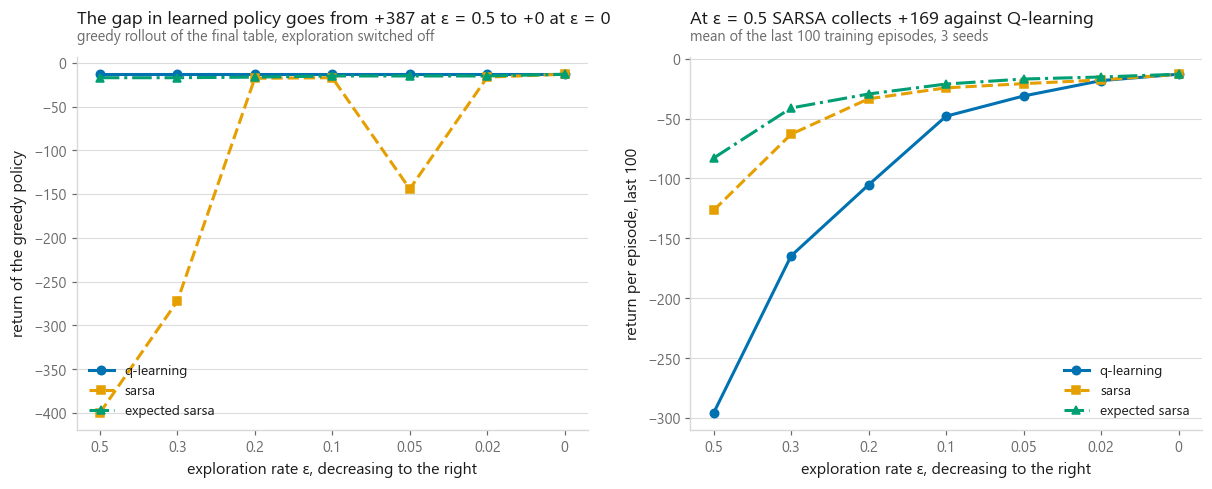

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.4))
x = np.arange(len(EPSILONS))

for ax, column, label, where in [
        (axes[0], "greedy return", "return of the greedy policy", "lower left"),
        (axes[1], "online, last 100", "return per episode, last 100", "lower right")]:
    for i, method in enumerate(METHODS):
        series = sweep[sweep["method"] == method].set_index("epsilon").loc[EPSILONS, column]
        ax.plot(x, series.to_numpy(), color=style.PALETTE[i], lw=2.0, ls=style.DASHES[i],
                marker=style.MARKERS[i], label=method)
    ax.set_xticks(x, [f"{e:g}" for e in EPSILONS])
    ax.set_xlabel("exploration rate ε, decreasing to the right")
    ax.set_ylabel(label)
    ax.legend(loc=where, fontsize=9)

gaps = sweep.pivot(index="epsilon", columns="method", values="greedy return")
online_gaps = sweep.pivot(index="epsilon", columns="method", values="online, last 100")
gap_high = float(gaps.loc[EPSILONS[0], "q-learning"] - gaps.loc[EPSILONS[0], "sarsa"])
gap_low = float(gaps.loc[0.0, "q-learning"] - gaps.loc[0.0, "sarsa"])
online_high = float(online_gaps.loc[EPSILONS[0], "sarsa"]
                    - online_gaps.loc[EPSILONS[0], "q-learning"])
style.title(axes[0],
            f"The gap in learned policy goes from {gap_high:+.0f} at ε = {EPSILONS[0]:g} "
            f"to {gap_low:+.0f} at ε = 0",
            "greedy rollout of the final table, exploration switched off")
style.title(axes[1],
            f"At ε = {EPSILONS[0]:g} SARSA collects {online_high:+.0f} against Q-learning",
            f"mean of the last 100 training episodes, {len(SEEDS)} seeds")
style.save(fig, FIG / "fig-04-epsilon-sweep.png")

### The two methods are the same algorithm at ε = 0

The right-hand end of that sweep is not an approximation. At $\varepsilon = 0$ the
epsilon-greedy policy is the greedy policy, so the action SARSA samples is always
the argmax, so $Q(s', a')$ is always $\max_{a'} Q(s', a')$. The two update rules
stop being similar and start being identical, line for line.

`choose` draws from the random stream whatever epsilon is, so with the same seed
the three methods also consume randomness identically, and the check below is
exact rather than approximate.

In [12]:
zero = {method: train(method, epsilon=0.0, seed=SEED) for method in METHODS}
zero_run = rollout(zero["q-learning"][0].argmax(axis=1))

print("at ε = 0, same seed, are the learned tables bit-identical?")
for method in METHODS[1:]:
    print(f"  q-learning vs {method:<15}: "
          f"{np.array_equal(zero['q-learning'][0], zero[method][0])}")
print(f"\nlargest difference anywhere in the tables: "
      f"{max(np.abs(zero['q-learning'][0] - zero[m][0]).max() for m in METHODS[1:]):.1e}")
print(f"\ngreedy route at ε = 0, all three: {zero_run['steps']} steps, "
      f"return {zero_run['return']:.0f}, reached the goal: {zero_run['reached']}")
print(f"mean return over the last 100 training episodes: "
      f"{zero['q-learning'][1][-100:].mean():.1f}")
print("\nNothing explores here. The table starts at zero and every reward is")
print("negative, so an unvisited action always looks better than a visited one.")
print("Optimistic initialisation is doing the exploring, and it is enough on a")
print("grid this small.")

at ε = 0, same seed, are the learned tables bit-identical?
  q-learning vs sarsa          : True
  q-learning vs expected sarsa : True

largest difference anywhere in the tables: 0.0e+00

greedy route at ε = 0, all three: 13 steps, return -13, reached the goal: True
mean return over the last 100 training episodes: -13.0

Nothing explores here. The table starts at zero and every reward is
negative, so an unvisited action always looks better than a visited one.
Optimistic initialisation is doing the exploring, and it is enough on a
grid this small.


### The learning rate, where expected SARSA earns its line of code

The environment is deterministic. Given $Q$, the only thing that varies between
two identical transitions is which $a'$ SARSA happens to draw, and expected SARSA
removes exactly that. So expected SARSA's update has no noise in it at all here,
and it should tolerate a step size that makes SARSA thrash.

That is a claim about the shape of a curve, so here is the curve.

In [13]:
ALPHAS = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

started = time.perf_counter()
alpha_rows = []
for alpha in ALPHAS:
    for method in METHODS:
        greedy, online = [], []
        for seed in SEEDS:
            Q, totals = train(method, alpha=alpha, seed=seed)
            greedy.append(rollout(Q.argmax(axis=1))["return"])
            online.append(totals[-100:].mean())
        alpha_rows.append({"alpha": alpha, "method": method,
                           "greedy return": np.mean(greedy),
                           "online, last 100": np.mean(online)})
alphas = pd.DataFrame(alpha_rows)
print(f"{len(ALPHAS)} learning rates x {len(METHODS)} methods x {len(SEEDS)} seeds "
      f"[{time.perf_counter() - started:.1f}s]\n")
print(alphas.pivot(index="alpha", columns="method", values="online, last 100")
      .to_string(float_format="{:.1f}".format))

7 learning rates x 3 methods x 3 seeds [8.3s]

method  expected sarsa  q-learning  sarsa
alpha                                    
0.05             -27.6       -42.2  -27.5
0.10             -23.0       -48.8  -26.5
0.20             -21.3       -49.8  -24.3
0.40             -20.4       -48.3  -25.4
0.60             -22.3       -49.7  -31.0
0.80             -23.3       -46.9  -59.4
1.00             -22.1       -45.2  -92.6


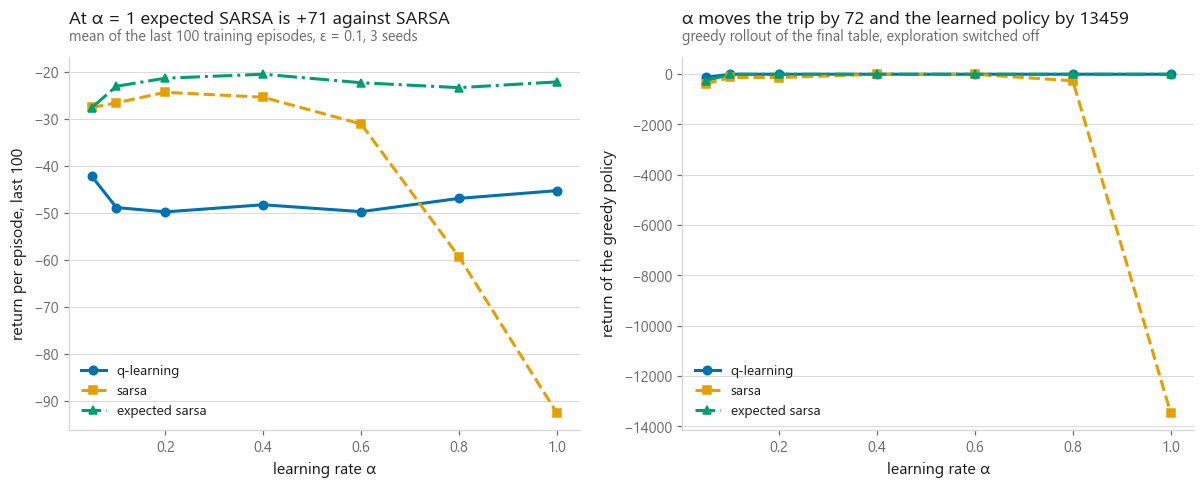

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.4))
online_by_alpha = alphas.pivot(index="alpha", columns="method", values="online, last 100")
greedy_by_alpha = alphas.pivot(index="alpha", columns="method", values="greedy return")

for ax, table, label in [(axes[0], online_by_alpha, "return per episode, last 100"),
                         (axes[1], greedy_by_alpha, "return of the greedy policy")]:
    for i, method in enumerate(METHODS):
        ax.plot(ALPHAS, table.loc[ALPHAS, method].to_numpy(), color=style.PALETTE[i],
                lw=2.0, ls=style.DASHES[i], marker=style.MARKERS[i], label=method)
    ax.set_xlabel("learning rate α")
    ax.set_ylabel(label)
    ax.legend(loc="best", fontsize=9)

es_top = float(online_by_alpha.loc[ALPHAS[-1], "expected sarsa"])
sa_top = float(online_by_alpha.loc[ALPHAS[-1], "sarsa"])
online_range = float(online_by_alpha.max().max() - online_by_alpha.min().min())
greedy_range = float(greedy_by_alpha.max().max() - greedy_by_alpha.min().min())
style.title(axes[0],
            f"At α = {ALPHAS[-1]:g} expected SARSA is {es_top - sa_top:+.0f} against SARSA",
            f"mean of the last 100 training episodes, ε = {EPSILON}, {len(SEEDS)} seeds")
style.title(axes[1],
            f"α moves the trip by {online_range:.0f} and the learned policy by "
            f"{greedy_range:.0f}",
            "greedy rollout of the final table, exploration switched off")
style.save(fig, FIG / "fig-05-alpha-sweep.png")

### What I would actually use

Expected SARSA costs a max and a mean per update and removes one of the two
sources of noise in the target. On a deterministic environment it removes the
only one, and the left panel above is the test of whether that buys anything at a
large step size. The same trick generalises: the target policy in that
expectation does not have to be the behaviour policy, and if you set it to the
greedy policy the expectation collapses to a `max` and you have written
Q-learning again. Expected SARSA is the general form and the other two are the
corners of it.

The reason to know all three is the two-bar figure, not the ranking. An agent has
a policy it is learning about and a policy it is behaving with, those can be the
same thing or different things, and every number you report is a number about one
of them. Report the online curve alone and you will pick SARSA. Report the final
greedy evaluation alone and you will pick Q-learning. Report both and the choice
stops being about algorithms and becomes a question about your deployment.

## Cheat sheet

| | |
|---|---|
| **SARSA** | On-policy. Target is $r + \gamma Q(s', a')$ with $a'$ the action it will take. Converges to $Q^\pi$ for the exploring policy |
| **Q-learning** | Off-policy. Target is $r + \gamma \max_{a'} Q(s', a')$. Converges to $Q^*$ regardless of how it behaved |
| **Expected SARSA** | On-policy, target is $r + \gamma \mathbb{E}_\pi[Q(s', a')]$. Same expectation as SARSA with the sampling noise of $a'$ removed |
| **Use SARSA when** | The exploration or the action noise is still there at deployment, and falling off the cliff is a real cost |
| **Use Q-learning when** | You train in a simulator and deploy the argmax, or you need to learn from logged or replayed data. [DQN](../06-deep-q-networks/) depends on this |
| **Main dials** | `alpha`, `epsilon`, `gamma`. Expected SARSA is the one that tolerates a large `alpha` |
| **Watch out** | Comparing an online learning curve against a final greedy evaluation and calling it one result. They are two results and they can disagree |
| **Sanity check** | Evaluate the greedy policy with exploration off, separately, every time. It is three lines and it changes the conclusion |
| **Next** | [Deep Q-Networks](../06-deep-q-networks/), which keeps Q-learning's `max` and replaces the table with a network |

## What to remember

1. The three methods share every line except the bootstrap term. On-policy and
   off-policy is a difference of one expression, not a difference of outlook.
2. Q-learning estimates the value of behaving optimally. SARSA estimates the
   value of the policy it is running, exploration included. Both are correct
   answers to different questions.
3. Score the policy and score the training separately. On this grid the better
   policy and the better training run belong to different agents.
4. SARSA's caution is a function of $\varepsilon$. Take the exploration away and
   the two methods converge, because at $\varepsilon = 0$ they are the same update.
5. Expected SARSA replaces a sampled action value with its expectation for the
   cost of one dot product, and the payoff shows up as tolerance to a large
   learning rate.
6. Set the target policy in expected SARSA to greedy and you get Q-learning. The
   three methods are one family.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [11-06 Deep Q-Networks](../06-deep-q-networks/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#ReinforcementLearning` `#SARSA` `#QLearning` `#TemporalDifference` `#OnPolicy`
`#Python` `#NumPy` `#MLTutorial` `#LearnMachineLearning` `#AI`